# Atrial Fibrillation (AF) classification with MIT-BIH AF Database

In this tutorial, we explore the classification of Atrial Fibrillation (AF) in Electrocardiogram (ECG) signals using a ResNet18-based neural network.

MIT-BIH AF Database:

Moody GB, Mark RG. A new method for detecting atrial fibrillation using R-R intervals. Computers in Cardiology. 10:227-230 (1983).

Data from PhysioNet:

Goldberger, A., Amaral, L., Glass, L., Hausdorff, J., Ivanov, P. C., Mark, R., ... & Stanley, H. E. (2000). PhysioBank, PhysioToolkit, and PhysioNet: Components of a new research resource for complex physiologic signals. Circulation [Online]. 101 (23), pp. e215–e220.

The following code block is for mounting Google Drive in a Google Colab notebook. It enables access to files stored in Google Drive from within the Colab environment, facilitating the loading and saving of data for your ECG Atrial Fibrillation classification project. The mounted drive will be available at the path '/content/drive' in the Colab environment. The force_remount=True parameter ensures that the drive is unmounted and then remounted, ensuring a fresh connection.

In [1]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:
# local data – adjust path as needed
import zipfile
with zipfile.ZipFile(r"C:\FinalYearProject\MIT-BIH_AF.zip.0.0.zip","r") as z:
    z.extractall(".")

Next, unzip the contents of "MIT-BIH_AF.zip" from your Google Drive into the current directory of your Colab environment.

*Note: In `processed_data`, 30-second samples are provided instead of raw signals.*


In [ ]:
!unzip -n /content/drive/MyDrive/MIT-BIH_AF.zip -d .

Archive:  /content/drive/MyDrive/MIT-BIH_AF.zip
   creating: ./files/
   creating: ./files/old/
  inflating: ./files/08455.hea       
  inflating: ./files/08215.dat       
  inflating: ./files/04908.atr       
  inflating: ./files/07162.hea-      
  inflating: ./files/08219.atr       
  inflating: ./files/08219.hea-      
  inflating: ./files/08434.hea-      
  inflating: ./files/00735.hea       
  inflating: ./files/05121.dat       
  inflating: ./files/07910.dat       
  inflating: ./files/04746.hea-      
  inflating: ./files/04746.atr       
  inflating: ./files/08378.dat       
  inflating: ./files/05261.hea-      
  inflating: ./files/SHA256SUMS.txt  
  inflating: ./files/04048.hea-      
  inflating: ./files/04936.xws       
  inflating: ./files/04936.dat       
  inflating: ./files/07879.qrs       
  inflating: ./files/05121.atr       
  inflating: ./files/08455.dat       
  inflating: ./files/04936.atr       
  inflating: ./files/05121.qrs       
  inflating: ./files/RECORDS  

We will then install the required libraries.


- MONAI is a domain-specific framework for medical imaging, designed to provide a consistent and efficient deep learning workflow across various medical imaging tasks.
- The wfdb library is commonly used for working with PhysioNet's data, which includes databases of physiological signals such as ECG (electrocardiogram). It provides tools for reading and processing biomedical signals stored in the WFDB (WaveForm DataBase) format.

In [4]:
%pip install monai wfdb

   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   --------------- ------------------------ 1.0/2.7 MB 4.7 MB/s eta 0:00:01
   ----------------------- ---------------- 1.6/2.7 MB 3.8 MB/s eta 0:00:01
   ----------------------------------- ---- 2.4/2.7 MB 3.5 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 3.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ------------------------------ --------- 0.8/1.0 MB 4.1 MB/s eta 0:00:01
   ---------------------------------------- 1.0/1.0 MB 3.7 MB/s eta 0:00:00

   ---- -----------------------------------  1/10 [multidict]
   ------------ ---------------------------  3/10 [aiohappyeyeballs]
   ---------------- -----------------------  4/10 [yarl]
   ---------------- -----------------------  4/10 [yarl]
   -------------------- -------------------  5/10 [soundfile]
   ---------------------------- -----------  7/10 [monai]
   ---------------------------- --------


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# Import packages
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob

In [6]:
# Load data (04043)
import wfdb
signal = wfdb.rdrecord("files/04043").p_signal.T
annotation = wfdb.rdann("files/04043", 'atr')
timestamps = annotation.sample
labels = annotation.aux_note

print(f"signal: {signal}, shape={signal.shape}")
print()
print(f"timestamps: {timestamps}, len={len(timestamps)}")
print()
print(f"labels: {labels}, len={len(labels)}")

signal: [[-0.415 -0.415 -0.43  ...  0.175  0.08  -0.03 ]
 [-0.395 -0.26  -0.185 ... -0.14  -0.16  -0.25 ]], shape=(2, 9205760)

timestamps: [     68  266498  376328 2585284 2602516 2634911 2739812 2745162 2779581
 2834739 2841728 3119235 3121706 3324526 3352183 3607124 3637519 3665624
 3680630 3690356 3707032 3714455 3729454 3757893 3850173 3864338 3882086
 3911965 3939729 3947348 3992719 4002976 4067053 4100718 4135455 4144613
 4180313 4184151 4207223 4216965 4232561 4397189 4429652 4469008 4475226
 4484786 4508435 4527258 4551868 4572558 4602709 4627077 4636998 4650429
 4700108 4846373 4859020 4977503 5001899 5025436 5047415 5064396 5076309
 5093223 5105440 5122383 5136042 5143706 5152531 5223157 5237640 5245920
 5258589 5269137 5310430 5328717 5383211 5412443 5446749 5481762 5504398
 5518464 5535882 5559927 5576037 5592280 5633072 5668367 5685492 5713187
 5719861 5746977 5774762 5797297 5822969 5859230 5866172 5891680 5931746
 6129598 6142319 6167966 6200373 6254934 6273886 6378723 

Load ECG (electrocardiogram) data for the specific record ("04043") from the MIT-BIH Atrial Fibrillation dataset.

We then define a dictionary `annotation_colors` that maps different annotation labels to specific colors. It then uses Matplotlib to create a plot of the ECG signal with annotated events, where each event is represented by a vertical dashed line with a corresponding label.

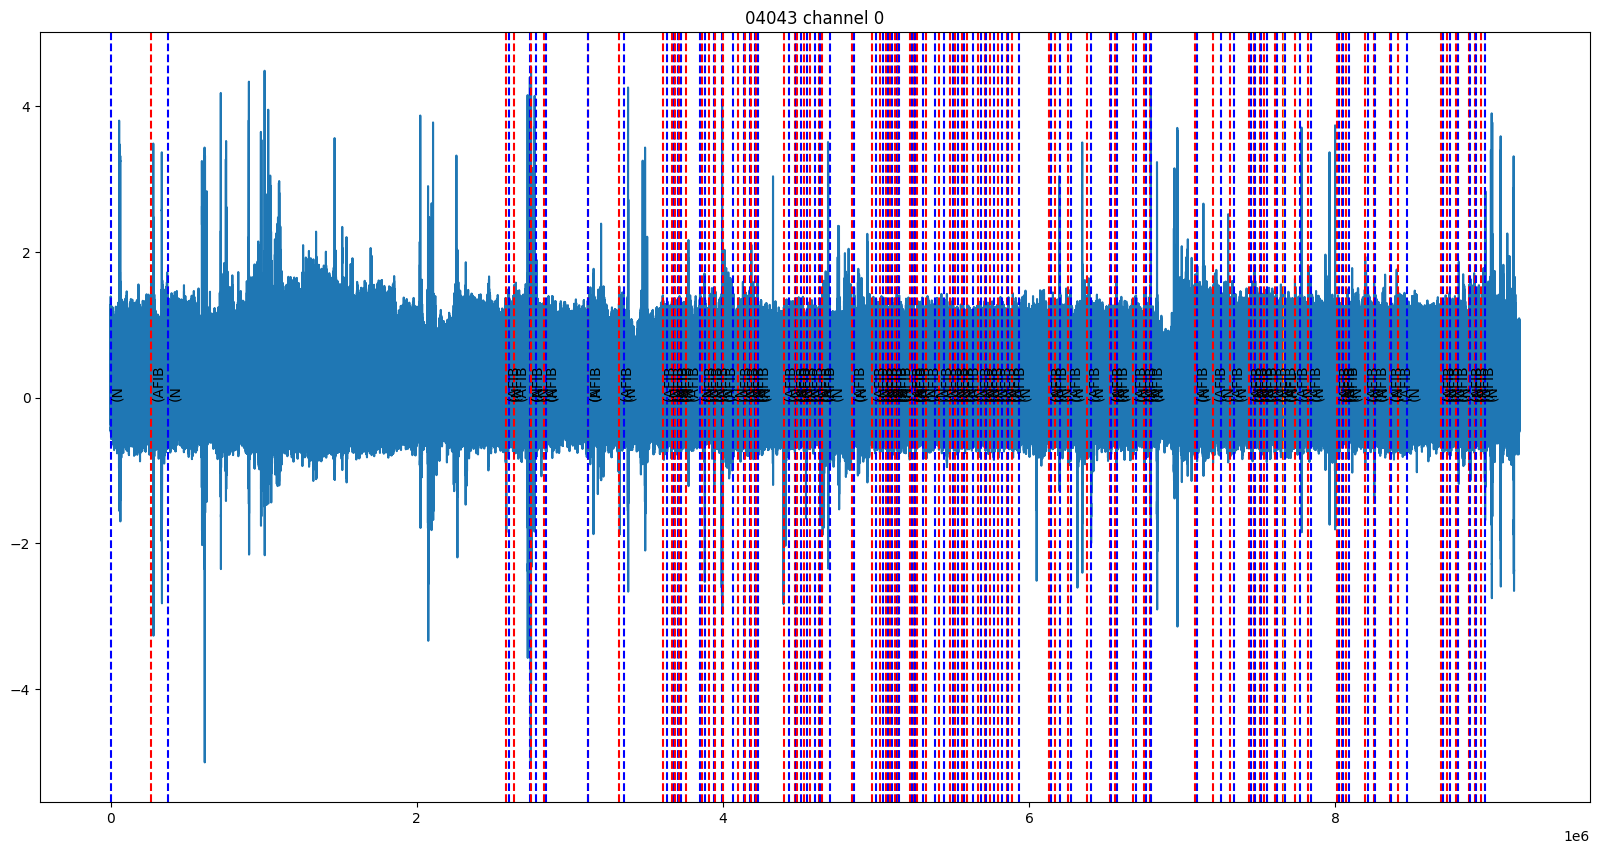

In [7]:
annotation_colors = {
    "(N": "blue",
    "(AFIB": "red",
    "(AFL": "orange",
    "(J": "green"
}

# Plot data with annotations
plt.figure(figsize=(20, 10))
plt.plot(signal[0])
for timestamp, label in zip(timestamps, labels):
    plt.axvline(x=timestamp, color=annotation_colors[label], linestyle="--")
    plt.text(timestamp, 0, label, rotation=90)
plt.title("04043 channel 0")
plt.show()
plt.close()

We will have to zoom in to see better.

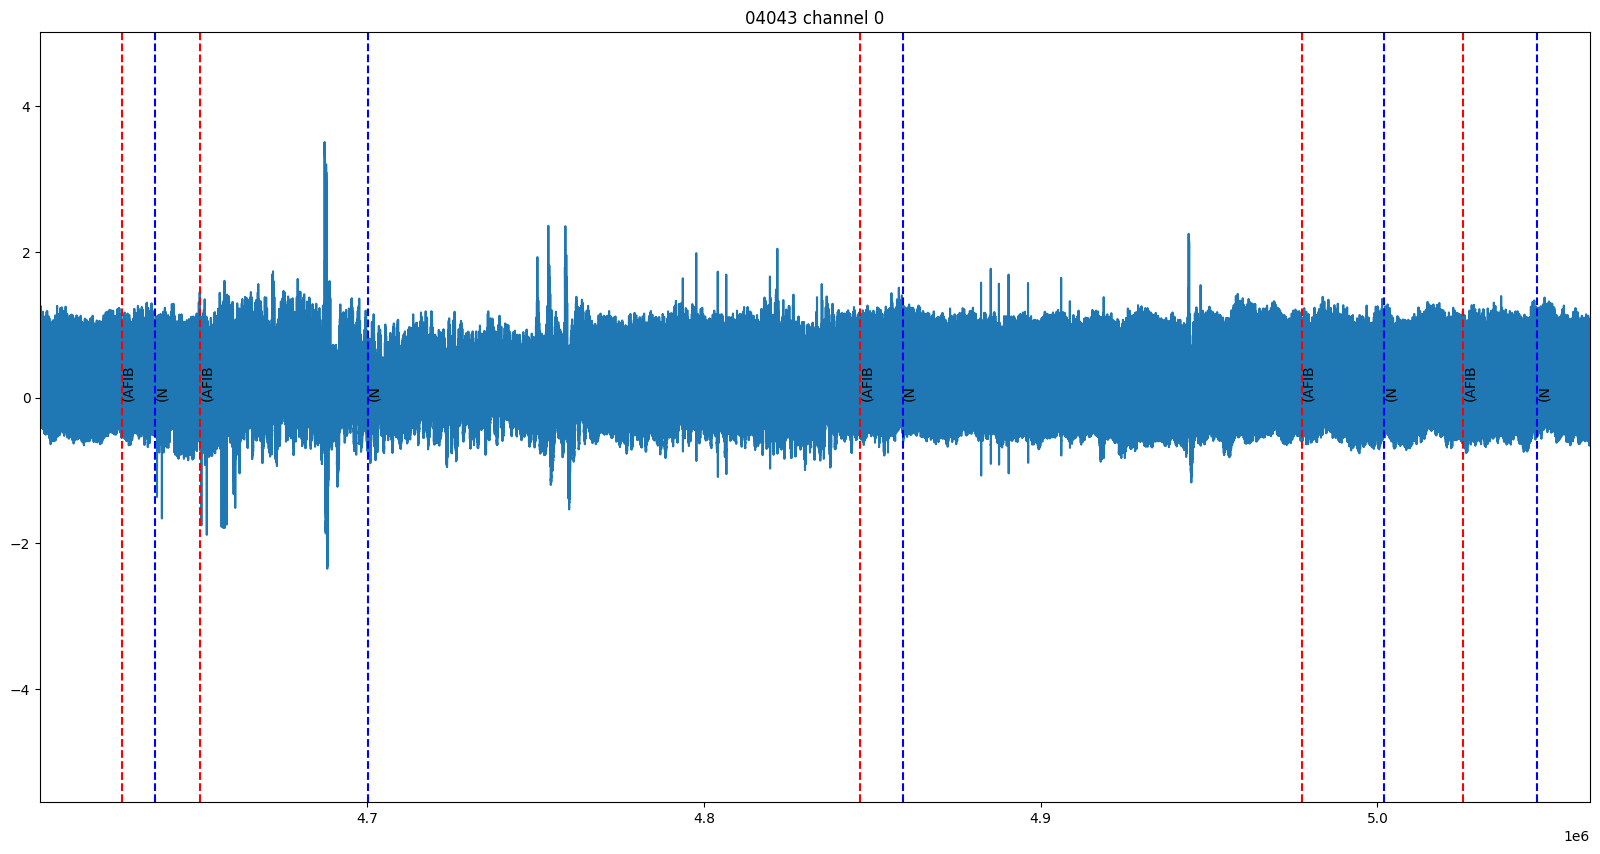

In [8]:
# Plot data with annotations and zoom in
start = int(0.5 * len(signal[0]))
end = int(0.55 * len(signal[0]))

plt.figure(figsize=(20, 10))
plt.plot(signal[0])
for timestamp, label in zip(timestamps, labels):
    if not start < timestamp < end:
         continue
    plt.axvline(x=timestamp, color=annotation_colors[label], linestyle="--")
    plt.text(timestamp, 0, label, rotation=90)
plt.title("04043 channel 0")
# Zoom in
plt.axis([start, end, None, None])
plt.show()
plt.close()

*Zoom in further.*

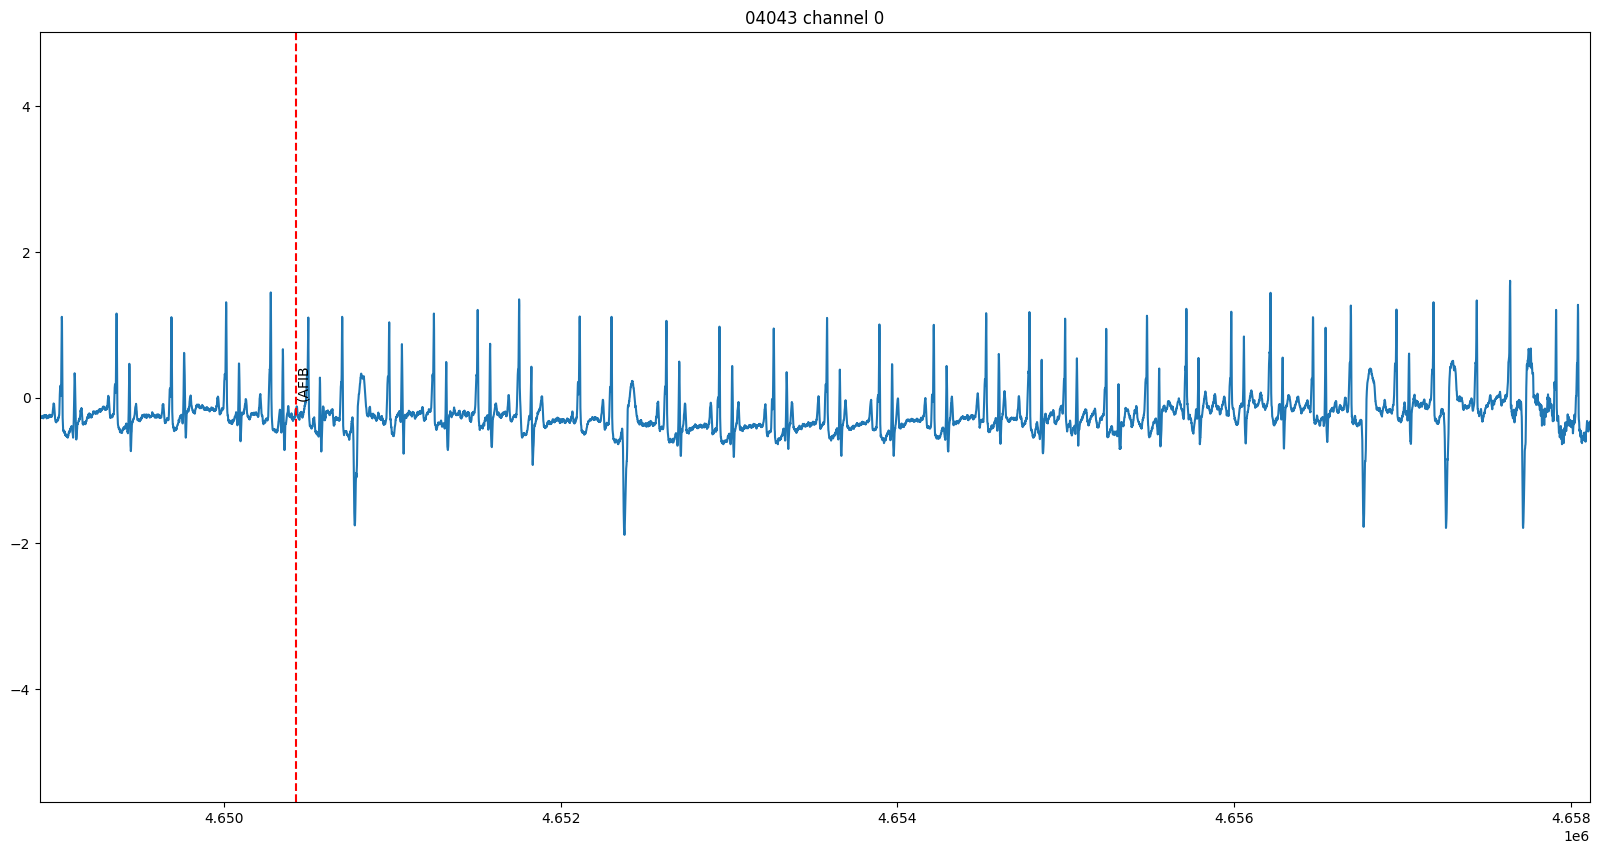

In [9]:
# Plot data with annotations and zoom in
start = int(0.505 * len(signal[0]))
end = int(0.506 * len(signal[0]))

plt.figure(figsize=(20, 10))
plt.plot(signal[0])
for timestamp, label in zip(timestamps, labels):
    if not start < timestamp < end:
         continue
    plt.axvline(x=timestamp, color=annotation_colors[label], linestyle="--")
    plt.text(timestamp, 0, label, rotation=90)
plt.title("04043 channel 0")
# Zoom in
plt.axis([start, end, None, None])
plt.show()
plt.close()

In [10]:
import os
import numpy as np
import wfdb
from glob import glob

# 1. Create Processed Data Directory
processed_data_dir = 'files/processed_data'
os.makedirs(processed_data_dir, exist_ok=True)
print(f"Created directory: {processed_data_dir}")

# 2. List Raw Record IDs
raw_files_dir = 'files/'
header_files = glob(os.path.join(raw_files_dir, '*.hea'))
record_ids = sorted(list(set([os.path.basename(f).split('.')[0] for f in header_files])))
print(f"Found {len(record_ids)} unique record IDs.")

# List to store record IDs that were successfully processed for filenames.txt
unique_raw_record_ids = []

# Constants for segmenting
segment_duration_seconds = 30 # Desired length of each ECG segment

total_processed_samples = 0

# 3. Process Raw ECG Records
for record_id in record_ids:
    print(f"Processing record: {record_id}")
    try:
        record = wfdb.rdrecord(os.path.join(raw_files_dir, record_id))
        annotation = wfdb.rdann(os.path.join(raw_files_dir, record_id), 'atr')

        signal = record.p_signal.T # Transpose to (channels, samples) for consistency
        fs = record.fs # Actual sampling frequency from record
        record_total_samples = signal.shape[1]

        segment_length_samples = fs * segment_duration_seconds

        # Prepare annotation states as a list of (timestamp, is_afib)
        # Assumes normal rhythm until the first annotation if it's not at sample 0
        annotation_states = []
        current_is_afib = False # Default state is non-AFIB

        # If the first annotation is not at the very beginning, assume normal up to that point
        if len(annotation.sample) > 0 and annotation.sample[0] > 0:
            annotation_states.append((0, False))

        for i in range(len(annotation.sample)):
            ts = annotation.sample[i]
            label = annotation.aux_note[i]

            is_afib_state_at_ts = False
            if label == '(AFIB':
                is_afib_state_at_ts = True
            elif label == '(N':
                is_afib_state_at_ts = False
            # Other labels are ignored as per the problem description focusing on AFIB vs non-AFIB

            # Add to annotation_states only if the state changes or it's the very first point
            if not annotation_states or annotation_states[-1][1] != is_afib_state_at_ts:
                # If there's a jump in timestamp without state change, or state change at same timestamp
                # Make sure to handle consecutive same state annotations without creating redundant points
                if annotation_states and annotation_states[-1][0] == ts:
                    annotation_states[-1] = (ts, is_afib_state_at_ts) # Update state at same timestamp
                else:
                    annotation_states.append((ts, is_afib_state_at_ts))
            
        # Ensure annotation_states covers the entire record duration.
        # Add a state at the very end of the record, using the last known state.
        if annotation_states:
            if annotation_states[0][0] > 0: # If the first annotation is not at 0, assume normal before it
                annotation_states.insert(0, (0, False))
            if annotation_states[-1][0] < record_total_samples:
                annotation_states.append((record_total_samples, annotation_states[-1][1]))
        else: # No annotations for this record, assume completely normal
            annotation_states.append((0, False))
            annotation_states.append((record_total_samples, False))

        # Remove duplicate consecutive timestamps (e.g., if (N then (AFIB at same timestamp, take the last)
        # This is handled by `if annotation_states[-1][0] == ts:` above, but let's ensure states are clean.
        # The critical part is that a label change implies the state starts at that timestamp.

        # Iterate through signal segments
        num_segments = record_total_samples // segment_length_samples

        for i in range(num_segments):
            segment_start_sample = i * segment_length_samples
            segment_end_sample = segment_start_sample + segment_length_samples

            segment_signal = signal[:, segment_start_sample:segment_end_sample]

            segment_label = 0 # Default to non-AFIB (0)

            # Check for AFIB overlap with this segment
            for j in range(len(annotation_states) - 1):
                state_start_ts, is_afib_in_interval = annotation_states[j]
                state_end_ts = annotation_states[j+1][0]

                # Check for overlap between [state_start_ts, state_end_ts) and [segment_start_sample, segment_end_sample)
                # Overlap exists if max(start1, start2) < min(end1, end2)
                overlap_start = max(state_start_ts, segment_start_sample)
                overlap_end = min(state_end_ts, segment_end_sample)

                if is_afib_in_interval and overlap_start < overlap_end:
                    segment_label = 1
                    break # Found AFIB in this segment, no need to check further

            # Save the processed segment
            output_filename = os.path.join(processed_data_dir, f"{record_id}_{i}_{segment_label}.npz")
            np.savez(output_filename, signal=segment_signal, label=segment_label, start=segment_start_sample, end=segment_end_sample)
            total_processed_samples += 1

        # Add record_id to the list for filenames.txt only if it was successfully processed
        unique_raw_record_ids.append(record_id)

    except Exception as e:
        print(f"Error processing record {record_id}: {e}")
        continue

print(f"Processed {total_processed_samples} 30-second segments in total.")

# 4. Generate Filenames List
filenames_txt_path = os.path.join(processed_data_dir, 'filenames.txt')
with open(filenames_txt_path, 'w') as f:
    for record_id in unique_raw_record_ids:
        f.write(f"{record_id}\n")
print(f"Generated {filenames_txt_path} with {len(unique_raw_record_ids)} record IDs.")

# 5. Final Task (Confirmation)
print(f"Data processing complete. Check '{processed_data_dir}' for generated .npz files and 'filenames.txt'.")

Created directory: files/processed_data
Found 25 unique record IDs.
Processing record: 00735
Error processing record 00735: sampto must be greater than sampfrom
Processing record: 03665
Error processing record 03665: sampto must be greater than sampfrom
Processing record: 04015
Processing record: 04043
Processing record: 04048
Processing record: 04126
Processing record: 04746
Processing record: 04908
Processing record: 04936
Processing record: 05091
Processing record: 05121
Processing record: 05261
Processing record: 06426
Processing record: 06453
Processing record: 06995
Processing record: 07162
Processing record: 07859
Processing record: 07879
Processing record: 07910
Processing record: 08215
Processing record: 08219
Processing record: 08378
Processing record: 08405
Processing record: 08434
Processing record: 08455
Processed 28104 30-second segments in total.
Generated files/processed_data\filenames.txt with 23 record IDs.
Data processing complete. Check 'files/processed_data' for ge

Now we try to load the filenames of all the MIT-BIH AF database. This is needed later, as we will have to ensure that every sample of a patient only appears in either training, validation or test set.

In [11]:
data_path = "files/processed_data"

# Get raw filenames
filenames = pd.read_csv(os.path.join(data_path, "filenames.txt"), header=None, dtype=str)[0].values.tolist()

print("Raw filenames:")
print(filenames)

Raw filenames:
['04015', '04043', '04048', '04126', '04746', '04908', '04936', '05091', '05121', '05261', '06426', '06453', '06995', '07162', '07859', '07879', '07910', '08215', '08219', '08378', '08405', '08434', '08455']


To ensure reproducibility, use `set_determinism` from MONAI library to ensure deterministic behavior during training and inference.

In [12]:
# Set determinism
from monai.utils import set_determinism
set_determinism(seed=42)

Perform a random shuffle of the raw filenames and then divides them into training, validation, and test sets.

In [13]:
# Split raw filenames into train, validation, and test sets
np.random.shuffle(filenames)

train_split = 0.8
validation_split = 0.1

train_filenames = filenames[:int(len(filenames) * train_split)]
validation_filenames = filenames[int(len(filenames) * train_split):int(len(filenames) * (train_split + validation_split))]
test_filenames = filenames[int(len(filenames) * (train_split + validation_split)):]

print(f"Number of files for training : {len(train_filenames)}")
print(f"Number of files for validation: {len(validation_filenames)}")
print(f"Number of files for test: {len(test_filenames)}")

Number of files for training : 18
Number of files for validation: 2
Number of files for test: 3


Files "07162" and "07859" cannot be used for validation or test since they are all comprised of AFIB.

In [14]:
# Only use file 07162 and 07859 for training
for filename in ["07162", "07859"]:
    if filename in validation_filenames:
        validation_filenames.remove(filename)
        validation_filenames.append(train_filenames[0])
        train_filenames.remove(train_filenames[0])
        train_filenames.append(filename)

    if filename in test_filenames:
        test_filenames.remove(filename)
        test_filenames.append(train_filenames[0])
        train_filenames.remove(train_filenames[0])
        train_filenames.append(filename)

We are ready to load in the samples.

In [15]:
# Get filenames of samples
samples = glob(os.path.join(data_path, "*.npz"))
print(f"First 5 samples: {samples[:5]}")
print(f"Number of samples: {len(samples)}")

First 5 samples: ['files/processed_data\\04015_0_0.npz', 'files/processed_data\\04015_1000_0.npz', 'files/processed_data\\04015_1001_0.npz', 'files/processed_data\\04015_1002_0.npz', 'files/processed_data\\04015_1003_0.npz']
Number of samples: 28104


Let us take a look at the first example.

`start` and `stop` record the timestamps cropped of the raw data.

signal: [[-0.275 -0.295 -0.31  ...  0.215  0.44   0.625]
 [-0.21  -0.2   -0.22  ... -0.01  -0.105 -0.175]]
label: 0
start: 0
end: 7500


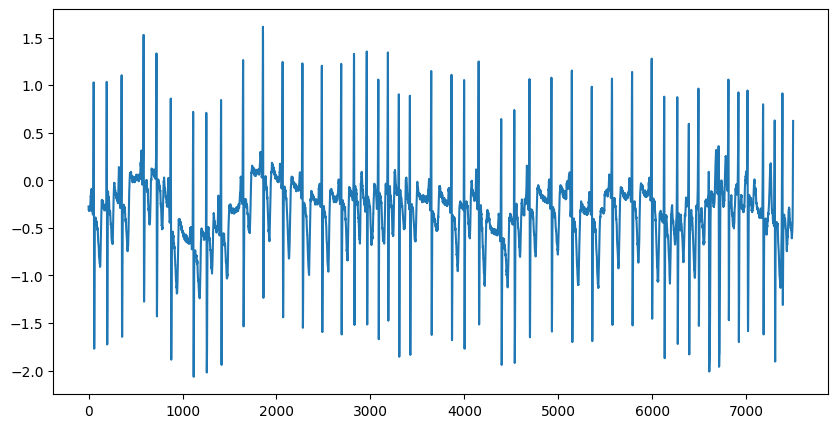

In [16]:
# Inspect the first sample
sample = np.load(samples[0])
for k, v in sample.items():
    print(f"{k}: {v}")

# Plot channel 0 of the signal
plt.figure(figsize=(10, 5))
plt.plot(sample["signal"][0])
plt.show()
plt.close()

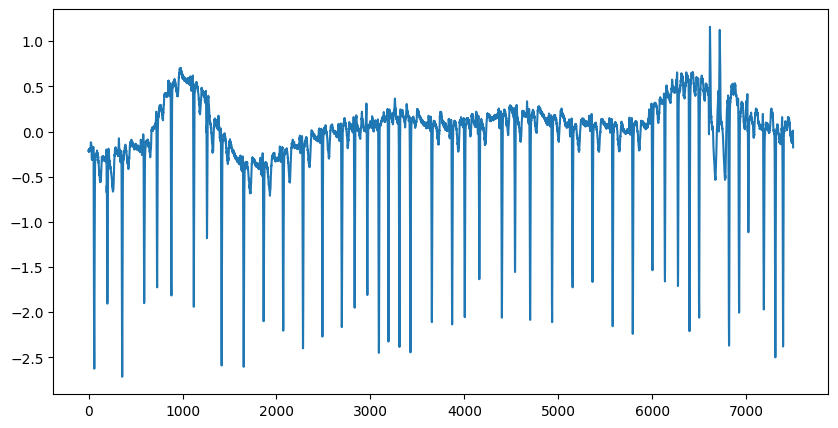

In [17]:
# Plot channel 1 of the signal
plt.figure(figsize=(10, 5))
plt.plot(sample["signal"][1])
plt.show()
plt.close()

We then organize the samples into training, validation, and test sets based on their filenames and creates dictionaries for each sample containing the ECG signal data and its corresponding label.

In [18]:
# Split data into train, validation, and test sets
train_data = []
validation_data = []
test_data = []
for sample in samples:
    # Initialize a dictionary to be put into our lists of samples
    d = {}
    # Extract the (raw) filename and label in the sample
    s = os.path.basename(sample).split(".")[0].split("_")
    filename = s[0]
    label = s[2]
    d["signal"] = sample
    d["label"] = int(label)
    # Put the sample in the corresponding list
    if filename in train_filenames:
        train_data.append(d)
    elif filename in validation_filenames:
        validation_data.append(d)
    elif filename in test_filenames:
        test_data.append(d)
    else:
        raise ValueError("Error: Filename not found in train, validation, or test sets")

print(f"Number of training samples: {len(train_data)}")
print(f"Number of validation samples: {len(validation_data)}")
print(f"Number of test samples: {len(test_data)}")

Number of training samples: 21969
Number of validation samples: 2454
Number of test samples: 3681


What exactly is in the dictionary?

In [19]:
print("An item in the list of samples:")
print(d)

An item in the list of samples:
{'signal': 'files/processed_data\\08455_9_0.npz', 'label': 0}


Note that we have not loaded the data yet, as loading will be done when we start training. Here we merely specify the path to the file.

Now we initialize the training process using PyTorch.

In [20]:
# Start training
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define model
from monai.networks.nets import resnet18
model = resnet18(spatial_dims=1, n_input_channels=2, num_classes=2).to(device)
print("Model:")
print(model)

# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Define loss function
loss_fn = nn.CrossEntropyLoss()

Using device: cuda
Model:
ResNet(
  (conv1): Conv1d(2, 64, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act): ReLU(inplace=True)
  (maxpool): MaxPool1d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): ResNetBlock(
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): ReLU(inplace=True)
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ResNetBlock(
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): ReLU(inplace=True)
 

Usually when handling ECG data, as a standard practice, more preprocessing methods such as Wiener filter and Butterworth filter will be applied to remove Gaussian noises and baseline wander. The following transform classes provide such functions:
- `NoiseRemovald(...)`: Reduce noise in the ECG signal using a Wiener filter.
- `BaselineWanderRemovald(...)`: Remove baseline wander by applying a high-pass Butterworth filter.
- `AlignCenterd(...)`: Align the signal by subtracting the median value from each channel.

In [21]:
from typing import Dict, Hashable, Mapping
from scipy.signal import butter, sosfilt, wiener
from monai.config import KeysCollection
from monai.config.type_definitions import NdarrayOrTensor
from monai.transforms import MapTransform
from monai.utils.type_conversion import convert_to_tensor, convert_to_numpy

import numpy as np

class NoiseRemovald(MapTransform):

    def __init__(self, keys: KeysCollection, allow_missing_keys: bool = False) -> None:
        super().__init__(keys, allow_missing_keys)

    def __call__(self, data: Mapping[Hashable, NdarrayOrTensor]) -> Dict[Hashable, NdarrayOrTensor]:
        d = dict(data)
        for key in self.key_iterator(d):
            signal = convert_to_numpy(d[key])

            # Wiener filter
            for chnl in range(signal.shape[0]):
                with np.errstate(all="ignore"): signal[chnl] = wiener(signal[chnl], mysize=5)

            d[key] = convert_to_tensor(signal, dtype="float32")
        return d

class BaselineWanderRemovald(MapTransform):

    def __init__(self, keys: KeysCollection, fs: int = 250, allow_missing_keys: bool = False) -> None:
        super().__init__(keys, allow_missing_keys)
        self.fs = fs

    def __call__(self, data: Mapping[Hashable, NdarrayOrTensor]) -> Dict[Hashable, NdarrayOrTensor]:
        d = dict(data)
        for key in self.key_iterator(d):
            signal = convert_to_numpy(d[key])

            # High-pass Butterworth filter
            butter_sos = butter(N=1, Wn=1, btype="hp", fs=self.fs, output="sos")
            for chnl in range(signal.shape[0]):
                signal[chnl] = sosfilt(butter_sos, signal[chnl])

            d[key] = convert_to_tensor(signal, dtype="float32")
        return d

class AlignCenterd(MapTransform):

    def __init__(self, keys: KeysCollection, allow_missing_keys: bool = False) -> None:
        super().__init__(keys, allow_missing_keys)

    def __call__(self, data: Mapping[Hashable, NdarrayOrTensor]) -> Dict[Hashable, NdarrayOrTensor]:
        d = dict(data)
        for key in self.key_iterator(d):
            signal = convert_to_numpy(d[key])

            # Subtract median
            for chnl in range(signal.shape[0]):
                signal[chnl] = signal[chnl] - np.median(signal[chnl])

            d[key] = convert_to_tensor(signal, dtype="float32")
        return d

The following set of transforms is designed to load and convert input data (such as ECG signals) into a format suitable for training neural networks. The final transformed data will consist of tensors for both the input signal and the corresponding labels.

- `LoadImaged(...)`: Loads image data from a specified dictionary key ("signal" in this case). It uses the NumpyReader to read data stored in the Numpy format (npz files) and extracts the "signal" key.

- `Resized(...)`: Resizes the spatial dimensions of the loaded image.

- `RandSpatialCropd(...)`: Randomly crops the spatial dimensions of the loaded image.

- `RandGaussianNoised(...)`: Adds random Gaussian noise to the loaded image.

- `ToTensord(...)`: Converts loaded data to PyTorch tensors. It specifies the keys ("signal" and "label") for which the conversion should be applied.

In [22]:
# Define transforms
from monai.transforms import (
    LoadImaged,
    Resized,
    RandSpatialCropd,
    RandGaussianNoised,
    RandScaleIntensityd,
    ToTensord,
    Compose,
)

transforms = Compose([
    LoadImaged(keys=["signal"], reader="NumpyReader", image_only=True, npz_keys=["signal"]),
    Resized(keys=["signal"], spatial_size=[2048]),
    NoiseRemovald(keys=["signal"]),
    BaselineWanderRemovald(keys=["signal"]),
    AlignCenterd(keys=["signal"]),
    #RandSpatialCropd(keys=["signal"], roi_size=[1024], random_size=False),
    #RandGaussianNoised(keys=["signal"], prob=0.5, mean=0.0, std=0.1),
    #RandScaleIntensityd(keys=["signal"], factors=0.1, prob=0.5),
    ToTensord(keys=["signal", "label"])
])

Time to visualize the transforms. Let us first look at the first training sample untouched:

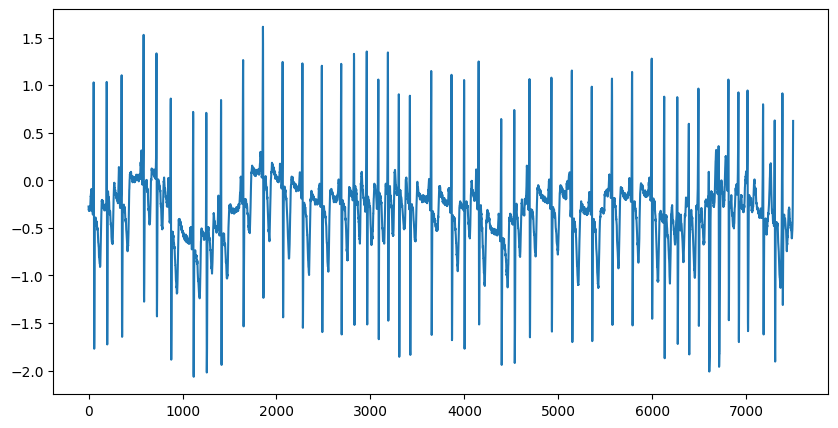

In [23]:
# Plot channel 0 of the first training sample
loader = LoadImaged(keys=["signal"], reader="NumpyReader", image_only=True, npz_keys=["signal"])
plt.figure(figsize=(10, 5))
plt.plot(loader(train_data[0])["signal"][0])
plt.show()
plt.close()

After transforms we get:

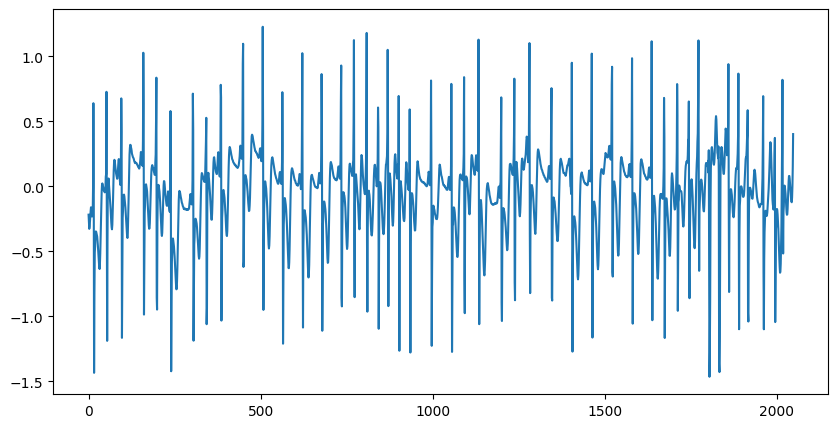

In [24]:
# Plot channel 0 of transformed first training sample
plt.figure(figsize=(10, 5))
plt.plot(transforms(train_data[0])["signal"][0])
plt.show()
plt.close()

Feel free to alter the transformations and observe the differences.

Datasets and data loaders are set up to efficiently handle training, validation, and testing. The use of `CacheDataset` is preferred when sufficient RAM is available, as it can lead to faster data loading.

Here RAM will be more than enough since we are using 1-dim data.

In [25]:
# Define datasets (CacheDatasets are faster but use more RAM)
from monai.data import CacheDataset
train_dataset = CacheDataset(data=train_data, transform=transforms, cache_rate=1.0, num_workers=4)
validation_dataset = CacheDataset(data=validation_data, transform=transforms, cache_rate=1.0, num_workers=4)
test_dataset = CacheDataset(data=test_data, transform=transforms, cache_rate=1.0, num_workers=4)

# Define datasets (Use regular datasets if no available RAM)
#from monai.data import Dataset
#train_dataset = Dataset(data=train_data, transform=transforms)
#validation_dataset = Dataset(data=validation_data, transform=transforms)
#test_dataset = Dataset(data=test_data, transform=transforms)

# Define data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Loading dataset: 100%|██████████| 3681/3681 [00:38<00:00, 95.24it/s] 


Next, we define three functions for training, validation, and testing.

1. Training Function (`train`):
    - Sets the model to training mode.
    - Iterates over batches in the training loader.
    - Performs forward pass, computes loss, and backpropagates to update model parameters.
    - Returns the average training loss.

2. Validation Function (`validate`):
    - Sets the model to evaluation mode (no weight updates).
    - Iterates over batches in the validation loader.
    - Computes validation loss without backpropagation.
    - Returns the average validation loss.

3. Testing Function (`test`):
    - Sets the model to evaluation mode.
    - Iterates over batches in the test loader.
    - Performs inference and collects true and predicted labels.
    - Prints a classification report using scikit-learn's `classification_report` for evaluation.

In [26]:
# Define training function
def train(model, device, train_loader, optimizer, loss_fn):
    model.train()
    train_loss = 0
    for batch in tqdm(train_loader):
        data = batch["signal"].to(device)
        target = batch["label"].to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = loss_fn(output, target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    return train_loss

# Define validation function
def validate(model, device, validation_loader, loss_fn):
    model.eval()
    validation_loss = 0
    with torch.no_grad():
        for batch in tqdm(validation_loader):
            data = batch["signal"].to(device)
            target = batch["label"].to(device)
            output = model(data)
            loss = loss_fn(output, target)
            validation_loss += loss.item()
    validation_loss /= len(validation_loader)
    return validation_loss

# Define test function
from sklearn.metrics import classification_report
def test(model, device, test_loader):
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for batch in tqdm(test_loader):
            data = batch["signal"].to(device)
            target = batch["label"].to(device)
            output = model(data)
            pred = output.argmax(dim=1, keepdim=True)
            y_true.append(target)
            y_pred.append(pred)
    y_true = torch.cat(y_true).cpu().numpy()
    y_pred = torch.cat(y_pred).cpu().numpy()
    print()
    print(classification_report(y_true, y_pred, target_names=["non-AFIB", "AFIB"], digits=4))

What follows is a common structure for training neural networks, where the model is saved if it achieves a better performance on the validation set compared to previous epochs. This helps prevent overfitting and provides the model with the best generalization performance on unseen data.

In [27]:
# Train model and save the best model
epochs = 10
best_loss = None
for epoch in range(epochs):
    train_loss = train(model, device, train_loader, optimizer, loss_fn)
    # Validation loss_fn can be changed into some other losses or metrics
    validation_loss = validate(model, device, validation_loader, loss_fn)
    print(f"Epoch: {epoch+1}/{epochs} - Train loss: {train_loss:.4f} - Validation loss: {validation_loss:.4f}")

    # Save the best model
    if epoch == 0:
        best_loss = validation_loss
        torch.save(model.state_dict(), "resnet18.pt")
    else:
        if validation_loss < best_loss:
            best_loss = validation_loss
            torch.save(model.state_dict(), "resnet18.pt")

100%|██████████| 77/77 [00:01<00:00, 48.34it/s]


Epoch: 1/10 - Train loss: 0.1222 - Validation loss: 0.1751


100%|██████████| 77/77 [00:01<00:00, 45.65it/s]


Epoch: 2/10 - Train loss: 0.0597 - Validation loss: 0.0758


100%|██████████| 77/77 [00:01<00:00, 48.94it/s]


...

Epoch: 8/10 - Train loss: 0.0370 - Validation loss: 0.0699


100%|██████████| 77/77 [00:01<00:00, 48.54it/s]


Epoch: 9/10 - Train loss: 0.0349 - Validation loss: 0.0894


100%|██████████| 77/77 [00:01<00:00, 53.57it/s]

Epoch: 10/10 - Train loss: 0.0329 - Validation loss: 0.0779


Finally, load the best-performing model (based on the lowest validation loss) and test it on the test dataset.

In [30]:
# Test model
model.load_state_dict(torch.load("resnet18.pt"))
test(model, device, test_loader)

100%|██████████| 116/116 [00:02<00:00, 46.56it/s]


              precision    recall  f1-score   support

    non-AFIB     0.8764    0.9129    0.8943      1756
        AFIB     0.9174    0.8826    0.8997      1925

    accuracy                         0.8970      3681
   macro avg     0.8969    0.8977    0.8970      3681
weighted avg     0.8979    0.8970    0.8971      3681



In [29]:
import torch
print(f"GPU Name: {torch.cuda.get_device_name(0)}")
print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

GPU Name: NVIDIA GeForce RTX 3050 Laptop GPU
GPU Memory: 4.29 GB
